In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
print(train.shape,test.shape)
n_train=train.shape[0]

all_features=pd.concat([train.iloc[:,1:-1],test.iloc[:,1:]])
value_features_column=all_features.columns[all_features.dtypes != 'object']
all_features[value_features_column]=all_features[value_features_column]\
    .apply(lambda x: (x-x.mean())/x.std(),axis=0)\
    .fillna(0.)
dummies_features=pd.get_dummies(all_features,dummy_na=True,dtype=float) 
#默认是bool,而混合float和bool会导致格式为 'object'
print(dummies_features.shape)

Id=pd.concat([train["Id"],test["Id"]])
dummies_features=pd.concat([Id,dummies_features],axis=1)

pd_train=pd.concat([dummies_features[:n_train],train.iloc[:,-1]],axis=1)
pd_test=dummies_features[n_train:]

(1460, 81) (1459, 80)
(2919, 330)


In [3]:
pd_train.head(),pd_train.shape

(   Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
 0   1    0.067320    -0.184443 -0.217841     0.646073    -0.507197   1.046078   
 1   2   -0.873466     0.458096 -0.072032    -0.063174     2.187904   0.154737   
 2   3    0.067320    -0.055935  0.137173     0.646073    -0.507197   0.980053   
 3   4    0.302516    -0.398622 -0.078371     0.646073    -0.507197  -1.859033   
 4   5    0.067320     0.629439  0.518814     1.355319    -0.507197   0.947040   
 
    YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_WD  SaleType_nan  \
 0      0.896679    0.523038    0.580708  ...          1.0           0.0   
 1     -0.395536   -0.569893    1.177709  ...          1.0           0.0   
 2      0.848819    0.333448    0.097840  ...          1.0           0.0   
 3     -0.682695   -0.569893   -0.494771  ...          1.0           0.0   
 4      0.753100    1.381770    0.468770  ...          1.0           0.0   
 
    SaleCondition_Abnorml  SaleCondition_AdjLand

```python
n_train=train.shape[0]
train_features=torch.tensor(dummies_features[:n_train].values,dtype=torch.float32)
train_labels=torch.tensor(train.iloc[:,-1].values.reshape(-1,1),dtype=torch.float32) #注意:这里标签是二维的
test_features=torch.tensor(dummies_features[n_train:].values,dtype=torch.float32)
```

In [4]:
class Nets(nn.Module):
    def __init__(self,net,lr,epoch=None):
        super().__init__()
        self.train_features=None
        self.train_labels=None
        self.test_features=None
        self.test_labels=None
        self.net=net
        self.lr=lr
        self.epoch=epoch
    def forward(self,X):
        return self.net(X)

In [5]:
def get_net_1(in_features):
    net=nn.Sequential(nn.Linear(in_features,1))
    return net
#num_epochs, lr, weight_decay, batch_size =250, 6, 5e-3, 64

In [6]:
def get_net_2(in_features):
    net=nn.Sequential(nn.Linear(in_features,64),
                      nn.ReLU(),
                      nn.Dropout(0.5),
                      nn.Linear(64,1))
    return net
#num_epochs, lr, weight_decay, batch_size = 100, 0.1, 1e-3, 64

In [400]:
def get_net_3(in_features):
    net=nn.Sequential(nn.Linear(in_features,256),
                      nn.ReLU(),
                      nn.Dropout(0.6),
                      nn.Linear(256,64),
                      nn.ReLU(),
                      nn.Dropout(0.4),
                      nn.Linear(64,1),
                     )
    return net

```python
#测试时写的
net1=Nets(get_net_1())
net2=Nets(get_net_1())
net3=Nets(get_net_2())
three_nets=[net1,net2,net3]
```

In [7]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier))<test_ratio*2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_: is_id_in_test_set(id_,test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [169]:
def init_nets(three_nets, pd_train):
    rng=np.random.default_rng(42)
    split_train, split_test=split_data_with_id_hash(pd_train, 0.2, "Id")
    # Id为唯一标识符
    
    for net in three_nets:
        sample_train=split_train.sample(frac=1,replace=True,random_state=rng)
         
        net.train_features=torch.tensor(sample_train.iloc[:,1:-1].values,dtype=torch.float32)
        net.train_labels=torch.tensor(sample_train.iloc[:,-1].values.reshape(-1,1),dtype=torch.float32)
        net.test_features=torch.tensor(split_test.iloc[:,1:-1].values,dtype=torch.float32)
        net.test_labels=torch.tensor(split_test.iloc[:,-1].values.reshape(-1,1),dtype=torch.float32)

----
train

In [9]:
def log_rmse(net, loss, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

In [10]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator.
    data_arrays: pytorch data, must have dimension 
    batch_size: the size of feature in each iter 
    is_train: shuffle or not
    """
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [11]:
def train_model(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls,test_ls=[],[]
    train_iter=load_array((train_features,train_labels), batch_size,is_train=True)

    optimizer=torch.optim.Adam(net.parameters(),
                               lr=learning_rate,
                               weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X,y in train_iter:
            optimizer.zero_grad()
            l=loss(net(X),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net,loss,train_features,train_labels))  #log_rmse不是用于训练的
        if test_labels is not None:
            test_ls.append(log_rmse(net,loss,test_features,test_labels))
    return train_ls,test_ls

In [12]:
def train_three(three_nets, num_epochs, weight_decay, batch_size,):
    i=0
    fig, axes = plt.subplots(1, 3,figsize=(9,3))
    for Net in three_nets:
        net=Net.net
        if Net.epoch:
            num_epochs=Net.epoch
        train_ls, valid_ls = train_model(net, Net.train_features, Net.train_labels,
                                   Net.test_features, Net.test_labels, 
                                   num_epochs, Net.lr,
                                   weight_decay, batch_size)
        
        d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                    xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                    legend=['train', 'valid'], yscale='log',
                    axes=axes[i],)
        i+=1
        print(f'网络{i }，训练 log rmse: {float(train_ls[-1]):f}, '
              f'验证 log rmse: {float(valid_ls[-1]):f}')

In [408]:
loss=nn.MSELoss()
in_features=pd_train.shape[1]-2 #一个ID,一个房价y

In [412]:
lr1, lr2, lr3=6, 0.1, 0.02
net1=Nets(get_net_1(in_features),lr1)
net2=Nets(get_net_2(in_features),lr2,50)
net3=Nets(get_net_3(in_features),lr3,50)
three_nets=[net1,net2,net3]
init_nets(three_nets,pd_train)

In [413]:
(net1.train_features.shape,net1.train_labels.shape,
net2.train_features.shape,net3.train_labels.shape,
(net1.test_features!=net2.test_features).sum(),)

(torch.Size([1169, 330]),
 torch.Size([1169, 1]),
 torch.Size([1169, 330]),
 torch.Size([1169, 1]),
 tensor(0))

网络1，训练 log rmse: 0.143915, 验证 log rmse: 0.162995
网络2，训练 log rmse: 0.191239, 验证 log rmse: 0.242559
网络3，训练 log rmse: 0.196480, 验证 log rmse: 0.214055


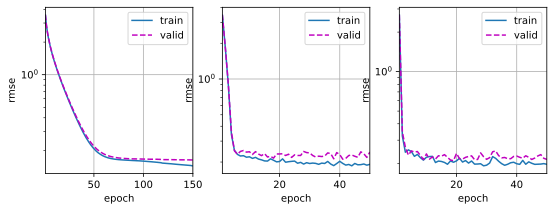

In [414]:
num_epochs, weight_decay, batch_size = 150, 1e-2, 64
train_three(three_nets, num_epochs,weight_decay, batch_size)

[注]:准备工作完成了;之前的数据处理工作真差劲...en,现在也没有修改/进行数据分析*

In [415]:
import math

In [416]:
original=torch.tensor(pd_train.iloc[:,1:].values,dtype=torch.float32)
unlabeled=torch.tensor(pd_test.values[:,1:],dtype=torch.float32)
#不带ID,original带了标签

In [417]:
original.shape,unlabeled.shape

(torch.Size([1460, 331]), torch.Size([1459, 330]))

In [418]:
def loss_2net(net_j: Nets, 
          net_k: Nets , 
          unlabeled: torch.Tensor
         ) -> torch.Tensor:
    loss_none=nn.MSELoss(reduction='none')

    h_j=net_j.net(unlabeled)
    h_k=net_k.net(unlabeled)
    clipped_preds_j = torch.clamp(h_j, 0.01, float('inf'))
    clipped_preds_k = torch.clamp(h_k, 0.01, float('inf'))
    rmse_tensor = torch.sqrt(loss_none(torch.log(clipped_preds_j),
                                torch.log(clipped_preds_k)))
    
    return rmse_tensor, h_j, h_k

In [419]:
def MeasureError(net_j: Nets,
                 net_k: Nets,
                 original: torch.Tensor
                ) -> float:
    rmse_jk, h_j, h_k =loss_2net(net_j,net_k,original[:,:-1])
    mask=(rmse_jk<EQUAL).reshape(-1)
    same_number=mask.sum()
    
    same_original=original[mask]
    same_h_j=h_j[mask]
    same_h_k=h_k[mask]
    loss_none=nn.MSELoss(reduction='none')
    clipped_same_j = torch.clamp(same_h_j, 0.01, float('inf'))
    clipped_same_k = torch.clamp(same_h_k, 0.01, float('inf'))
    rmse_j_ori = torch.sqrt(loss_none(torch.log(clipped_same_j),
                                torch.log(same_original[:,-1:])))
    rmse_k_ori = torch.sqrt(loss_none(torch.log(clipped_same_k),
                                torch.log(same_original[:,-1:])))
    rmse_jk_ori=(rmse_j_ori+rmse_k_ori)/2.

    same_wrong_number=(rmse_jk_ori>EQUAL).sum()
    e=same_wrong_number/same_number
    return e

In [420]:
def Subsample(net_i: Nets,
              s: float,
             ) -> None:
    row=net_i.train_features_new.shape[0]
    #percent=s/row
    #mask=torch.rand(row)<percent  #数量不稳定
    s=math.ceil(s)
    indices = torch.randperm(row)[:s]   # 返回一个包含 s 个不重复索引的 1D 张量
    net_i.train_features_new = net_i.train_features_new[indices]  # 根据索引选取
    net_i.train_labels_new=net_i.train_labels_new[indices]
    

In [421]:
for net_i in three_nets:
    net_i.e_pre=0.5
    net_i.l=0

In [458]:
EQUAL=0.08
for i in range(3):
    net_i=three_nets[i]
    net_j=three_nets[(i+1)%3]
    net_k=three_nets[(i+2)%3]

    net_i.net.eval();
    net_j.net.eval();
    net_k.net.eval();
    
    net_i.train_features_new=None
    net_i.train_labels_new=None
    net_i.update=False
    
    net_i.e=MeasureError(net_j,net_k,original)
    if net_i.e<net_i.e_pre:
        rmse_tensor, h_j, h_k=loss_2net(net_j,net_k,unlabeled)
        mask=(rmse_tensor<EQUAL).reshape(-1)
        net_i.train_features_new=unlabeled[mask]
        net_i.train_labels_new=(h_j+h_k)/2.
        
        if net_i.l==0:
            net_i.l=net_i.e/(net_i.e_pre-net_i.e)+1
        if net_i.l<net_i.train_features_new.shape[0]:
            if net_i.e*net_i.train_features_new.shape[0]<net_i.e_pre*net_i.l:
                net_i.update=True
            elif net_i.l>net_i.e/(net_i.e_pre-net_i.e):
                s=net_i.e_pre*net_i.l/net_i.e-1
                Subsample(net_i,s) #留下s个样本
                net_i.update=True


[attention 3/19]:需要写一个MeasureError和Subsample,需要处理样本的放置,即留下的那个net_i.train_

In [459]:
net1.update,net2.update,net3.update

(False, False, False)

In [460]:
net1.e,net2.e,net3.e

(tensor(0.0996), tensor(0.1357), tensor(0.1995))

In [461]:
(net1.train_features_new.shape,
 net2.train_features_new.shape,
 net3.train_features_new.shape)

AttributeError: 'NoneType' object has no attribute 'shape'

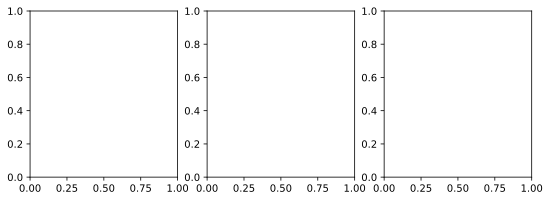

In [462]:
num_epochs, weight_decay, batch_size = 30, 1e-2, 64
net2.num_epochs=30
net3.num_epochs=30
i=-1
fig, axes = plt.subplots(1, 3,figsize=(9,3))
for net_i in three_nets:
    i+=1
    if net_i.update:
        net=net_i.net
        net_i.train_features=torch.concat([net_i.train_features,net_i.train_features_new])
        net_i.train_labels=torch.concat([net_i.train_labels,net_i.train_labels_new]).detach()
        ## 不知道是因为哪一步,保存了带有grad_fn的张量 en... 先用.detach切断再说
        ## 使用了net(X) 就会有grad_fn
        if net_i.epoch:
            num_epochs=net_i.epoch
        train_ls, valid_ls = train_model(net, net_i.train_features, net_i.train_labels,
                                   net_i.test_features, net_i.test_labels, 
                                   num_epochs, net_i.lr,
                                   weight_decay, batch_size)
        
        
        print(f'网络{i+1}，训练 log rmse: {float(train_ls[-1]):f}, '
              f'验证 log rmse: {float(valid_ls[-1]):f}')

        
        d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                    xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                    legend=['train', 'valid'], yscale='log',
                    axes=axes[i],)
        
        net_i.e_pre=net_i.e
        net_i.l=net_i.train_features_new.shape[0]

In [463]:
def get_logrmse(y_hat, y, loss_mean):
    clipped=torch.clamp(y_hat, 0.01, float('inf'))
    rmse = torch.sqrt(loss_mean(torch.log(clipped),
                                torch.log(y)))
    return rmse

In [472]:
def test(*nets) -> torch.Tensor:
    '''
    最后返回的是一个元素的张量,但是由于可能为None,所以函数里没有用.item(),需要在外部调用
    '''
    loss_mean=nn.MSELoss(reduction='mean')
    li_train_y_hat, li_test_y_hat = [],[]
    rmse_train=None
    
    for net_i in nets:
        li_train_y_hat.append(net_i.net(net_i.train_features))
        li_test_y_hat.append(net_i.net(net_i.test_features))

    if len(nets)==1:
        train_y_hat=li_train_y_hat[0]
        rmse_train=get_logrmse(train_y_hat,net_i.train_labels,loss_mean)
    
    test_y_hat=sum(li_test_y_hat)/len(nets) 
    #对三个学习器的结果平均; 事实上后面提交的时候还进行了加权  en,有时间改一下,这里也加权一下
    rmse_test=get_logrmse(test_y_hat,net_i.test_labels,loss_mean)

    return rmse_train,rmse_test

In [473]:
i=1
for net_i in three_nets:
    rmse_train, rmse_test=test(net_i)
    print(f'net{i}: train rmse loss: {rmse_train:.6f}, '
          f' test rmse loss: {rmse_test:.6f}')
    i+=1

net1: train rmse loss: 0.143298,  test rmse loss: 0.186431
net2: train rmse loss: 0.057063,  test rmse loss: 0.193252
net3: train rmse loss: 0.017604,  test rmse loss: 0.191139


In [482]:
def weight_average():
    '''这只是一个测试'''
    loss_mean=nn.MSELoss(reduction='mean')
    i=0
    rmse_test=torch.zeros(3,1,1)
    for net_i in three_nets:
        _, rmse=test(net_i)
        rmse_test[i,0,0]=rmse.item()
        i+=1
        
    rmse_test_to1=rmse_test/rmse_test.sum()
    test_features=three_nets[0].test_features
    total_prediction=torch.stack((three_nets[0].net(test_features),
                                  three_nets[1].net(test_features),
                                  three_nets[2].net(test_features),
                                 ),dim=0) #(3,n,1)
    final=(rmse_test_to1*total_prediction).sum(dim=0)
    rmse_test_weight=get_logrmse(final,net_i.test_labels,loss_mean)
    return rmse_test_weight
rmse_test_weight=weight_average()
rmse_test_weight

tensor(0.1331, grad_fn=<SqrtBackward0>)

In [483]:
_, rmse_test=test(*three_nets)
print(f'net_average: '
      f'average test rmse loss: {rmse_test:.6f}\n'
      f'average with weight (test): {rmse_test_weight:.6f}')

net_average: average test rmse loss: 0.132857
average with weight (test): 0.133081


In [391]:
def predict_andToCSV(unlabeled,*three_nets):
    i=0
    rmse_test=torch.zeros(3,1,1)
    for net_i in three_nets:
        _, rmse=test(net_i)
        rmse_test[i,0,0]=rmse.item()
        i+=1
    rmse_test_to1=rmse_test/rmse_test.sum()
    total_prediction=torch.stack((three_nets[0].net(unlabeled),
                                  three_nets[1].net(unlabeled),
                                  three_nets[2].net(unlabeled),
                                 ),dim=0) #(3,n,1)
    final=(rmse_test_to1*total_prediction).sum(dim=0).detach().numpy()

    prediction=pd.Series(final.reshape(-1))
    prediction.name=pd_train.columns[-1]
    submit=pd.concat([pd_test['Id'],prediction],axis=1)
    submit.to_csv('Tri-training-submission.csv',
                  index=False,
                  float_format='%.6f',)
    return submit
    

In [392]:
submission=predict_andToCSV(unlabeled,*three_nets)
submission.head()

,Id,SalePrice
0,1461,111079.601562
1,1462,161387.343750
2,1463,182779.890625
3,1464,196420.203125
4,1465,186915.890625


结果并不好.  考虑:
- ~~前面划分了验证集,但是这三个模型的验证集并不一样.~~ 已修改
- EQUAL设置的可能不合适
- ~~试试用三个线性的,diversity应该够~~  感觉这样应该没有三个不同的效果好
- 最后应该在加上验证集一起训练,怎么加

!!**并且需要整理代码,分模块等等工作**